In [1]:
# %% [markdown]
# # 02 — Encoding, Transformación y Balanceo
# ## Proyecto VI · Clasificación · Austin Animal Center
#
# **Objetivo:** Preparar el dataset para el modelado baseline.
# Transformamos variables, aplicamos encoding, dividimos los datos
# y balanceamos la clase minoritaria con SMOTE.
#
# **Input:**  `data/processed/animal_ready_for_modeling.csv`
# **Output:** `data/processed/splits_procesados.npz`
#
# ---
# ### Índice
# 1. Carga del dataset
# 2. Transformación logarítmica — AgeInDays
# 3. Label Encoding del target
# 4. Split estratificado 60/20/20
# 5. Preprocesador — RobustScaler + OHE + OrdinalEncoder
# 6. SMOTE — balanceo de la clase At Risk
# 7. Guardar splits para trabajo en equipo

# %% [markdown]
# ---
# ## 1. Carga del dataset
#
# Cargamos el dataset limpio generado en el preprocesamiento.
# Partimos de `df_pd2` que ya tiene:
# - Breed y Color eliminados
# - Sex limpio (sin nulls)
# - 110.847 filas, 10 columnas

# %%
import numpy as np
import pandas as pd
from sklearn.preprocessing import (RobustScaler, OneHotEncoder,
                                   OrdinalEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

df_pd2 = pd.read_csv("../data/processed/animal_ready_for_modeling.csv")

print(f"Shape: {df_pd2.shape}")
print(f"Columnas: {df_pd2.columns.tolist()}")
print(f"Nulos: {df_pd2.isnull().sum().sum()}")

# %% [markdown]
# ---
# ## Configuración global
#
# Definimos aquí todas las constantes que usarán los notebooks
# de modelado para garantizar consistencia entre compañeros.
#
# | Variable | Contenido |
# |---|---|
# | `FEATURES_NUM` | Features numéricas → RobustScaler |
# | `FEATURES_OHE` | Features nominales → OneHotEncoder |
# | `FEATURES_ORDINAL` | Features ordinales → OrdinalEncoder |
# | `TARGET` | Variable objetivo |
# | `CLASS_ORDER` | Orden fijo de clases para métricas |

# %%
TARGET      = "OutcomeClass"
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

FEATURES_NUM     = ["AgeInDays_log"]
FEATURES_OHE     = ["AnimalType", "Sex", "IntakeType",
                     "IntakeCondition", "breed_type",
                     "Color_grouped", "Season"]
FEATURES_ORDINAL = ["AgeGroup"]

AGE_ORDER = [["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
              "Adulto (3-7a)", "Senior (>7a)"]]

print("Configuración:")
print(f"  Target:           {TARGET}")
print(f"  Features num:     {FEATURES_NUM}")
print(f"  Features OHE:     {FEATURES_OHE}")
print(f"  Features ordinal: {FEATURES_ORDINAL}")

# %% [markdown]
# ---
# ## 2. Transformación logarítmica — AgeInDays
#
# El EDA reveló que AgeInDays tiene un **skewness de 2.158** —
# distribución muy sesgada a la derecha con animales de hasta 8.760 días.
#
# Aplicamos `log1p` (logaritmo de x+1) antes de escalar porque:
# - Comprime los valores extremos acercando media y mediana
# - Beneficia a **LogisticRegression y SVM** que son sensibles a la escala
# - **No afecta** a árboles ni ensemble (invariantes a transformaciones monótonas)
# - `log1p` en lugar de `log` evita problemas con valores = 0

# %%
df_pd2["AgeInDays_log"] = np.log1p(df_pd2["AgeInDays"])

print("Comparativa AgeInDays:")
print(f"  Skewness original: {df_pd2['AgeInDays'].skew():.3f}  ← sesgado")
print(f"  Skewness log1p:    {df_pd2['AgeInDays_log'].skew():.3f}  ← mucho mejor")
print(f"\n  Media original:    {df_pd2['AgeInDays'].mean():.0f} días")
print(f"  Media log1p:       {df_pd2['AgeInDays_log'].mean():.3f}")
print(f"\n  Mediana original:  {df_pd2['AgeInDays'].median():.0f} días")
print(f"  Mediana log1p:     {df_pd2['AgeInDays_log'].median():.3f}")

# %% [markdown]
# ---
# ## 3. Label Encoding del target
#
# Sklearn necesita que el target sea numérico.
# Usamos `LabelEncoder` con un orden fijo (`CLASS_ORDER`) para que
# todos los compañeros tengan la misma codificación.
#
# ⚠️ Guardamos `le_target` — lo necesitaremos para interpretar
# las predicciones del modelo (número → nombre de clase).

# %%
le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y     = df_pd2[TARGET]
y_enc = le_target.transform(y)

print("Target codificado:")
for i, c in enumerate(le_target.classes_):
    n   = (y_enc == i).sum()
    pct = n / len(y_enc) * 100
    print(f"  {i} → {c:<22} ({n:,} registros, {pct:.1f}%)")

# %% [markdown]
# ---
# ## 4. Split estratificado 60/20/20
#
# Dividimos los datos en tres particiones:
#
# | Partición | % | Uso |
# |---|---|---|
# | Train | 60% | Entrenar el modelo |
# | Validación | 20% | Ajustar hiperparámetros |
# | Test | 20% | Evaluación final (solo una vez) |
#
# Usamos `stratify` para preservar la proporción de clases en cada split.
# Sin esto, con At Risk al 3.7% algún fold podría quedar sin ejemplos
# de esa clase y el modelo nunca aprendería a detectarla.
#
# **Por qué 60/20/20 y no 70/15/15:**
# Con 110.847 registros y desbalance severo conviene reservar
# más para validación y test para que las métricas sean fiables.

# %%
X = df_pd2[FEATURES_NUM + FEATURES_OHE + FEATURES_ORDINAL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 × 0.80 = 0.20 → resultado final: 60/20/20

print("División estratificada 60/20/20:")
print(f"  Train:      {X_train.shape[0]:>7,} filas  (60%)")
print(f"  Validación: {X_val.shape[0]:>7,} filas  (20%)")
print(f"  Test:       {X_test.shape[0]:>7,} filas  (20%)")

print("\nProporción At Risk por split (debe ser ~3.7% en todos):")
at_risk_idx = le_target.transform(["At Risk"])[0]
for nombre, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = (y_split == at_risk_idx).mean() * 100
    ok  = "✅" if 3.5 <= pct <= 4.0 else "⚠️"
    print(f"  {ok} At Risk en {nombre}: {pct:.2f}%")

# %% [markdown]
# ---
# ## 5. Preprocesador — RobustScaler + OHE + OrdinalEncoder
#
# Usamos `ColumnTransformer` para aplicar un transformador distinto
# a cada tipo de variable en un solo paso:
#
# | Transformador | Variables | Justificación |
# |---|---|---|
# | `RobustScaler` | AgeInDays_log | Resiste outliers usando mediana en lugar de media |
# | `OneHotEncoder` | 7 nominales | Convierte categorías sin orden a columnas binarias |
# | `OrdinalEncoder` | AgeGroup | Preserva el orden natural Cachorro → Senior |
#
# **Regla crítica:** `fit_transform` solo en train.
# Val y test usan solo `transform` con los parámetros aprendidos del train.
# Si hicieras fit en val/test, estarías dejando que los datos de evaluación
# influyan en la normalización — otra forma de data leakage.

# %%
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler",  RobustScaler(),
                    FEATURES_NUM),
        ("ohe",     OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False),
                    FEATURES_OHE),
        ("ordinal", OrdinalEncoder(categories=AGE_ORDER,
                                   handle_unknown="use_encoded_value",
                                   unknown_value=-1),
                    FEATURES_ORDINAL),
    ],
    remainder="drop"
)

X_train_prep = preprocessor.fit_transform(X_train)   # fit + transform
X_val_prep   = preprocessor.transform(X_val)          # solo transform
X_test_prep  = preprocessor.transform(X_test)         # solo transform

ohe_cols = preprocessor.named_transformers_["ohe"]\
                        .get_feature_names_out(FEATURES_OHE)
all_cols = FEATURES_NUM + list(ohe_cols) + FEATURES_ORDINAL

print("Shape tras preprocesado:")
print(f"  X_train_prep: {X_train_prep.shape}")
print(f"  X_val_prep:   {X_val_prep.shape}")
print(f"  X_test_prep:  {X_test_prep.shape}")
print(f"\nTotal features generadas: {len(all_cols)}")
print(f"  Numéricas:  {len(FEATURES_NUM)}")
print(f"  OHE:        {len(ohe_cols)}  → {list(ohe_cols)}")
print(f"  Ordinales:  {len(FEATURES_ORDINAL)}")

# %% [markdown]
# ---
# ## 6. SMOTE — balanceo de la clase At Risk
#
# Con ratio 13.2:1 (Adoption vs At Risk), los modelos aprenden
# muy bien a identificar adopciones pero casi nunca detectan
# animales en riesgo — exactamente el error más grave posible.
#
# **SMOTE** (Synthetic Minority Oversampling Technique) genera
# ejemplos sintéticos de At Risk interpolando entre ejemplos reales:
# busca los k vecinos más cercanos de cada ejemplo At Risk
# y crea nuevos puntos en el espacio entre ellos.
#
# **Por qué después del preprocesador:**
# SMOTE necesita datos numéricos para interpolar.
# Aplicarlo antes generaría strings sintéticos sin sentido.
#
# **Por qué solo en train:**
# Val y test deben reflejar la distribución real del problema.
# Si los balancearas, evaluarías el modelo en condiciones
# que no existen en producción y las métricas mentirían.

# %%
from imblearn.over_sampling import SMOTE

print("Distribución ANTES de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n   = (y_train == idx).sum()
    pct = n / len(y_train) * 100
    bar = "█" * int(pct / 2)
    print(f"  {clase:<22} {n:>6,}  ({pct:4.1f}%)  {bar}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("\nDistribución DESPUÉS de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n   = (y_train_bal == idx).sum()
    pct = n / len(y_train_bal) * 100
    bar = "█" * int(pct / 2)
    print(f"  {clase:<22} {n:>6,}  ({pct:4.1f}%)  {bar}")

print(f"\nTrain original:   {X_train_prep.shape[0]:>7,} filas")
print(f"Train balanceado: {X_train_bal.shape[0]:>7,} filas")
print(f"Sintéticos gen.:  {X_train_bal.shape[0] - X_train_prep.shape[0]:>7,}")
print(f"\n✅ Val y Test NO se tocan — representan la realidad")
print(f"\nTienes dos versiones de train para comparar en el baseline:")
print(f"  X_train_prep + y_train     → modelos con class_weight='balanced'")
print(f"  X_train_bal  + y_train_bal → modelos con SMOTE")

# %% [markdown]
# ---
# ## 7. Guardar splits para trabajo en equipo
#
# Guardamos todos los arrays en un archivo `.npz` para que
# cualquier compañero pueda cargarlos directamente sin
# repetir todo el pipeline.
#
# **Cómo cargarlos en otro notebook:**
# ```python
# import numpy as np
# data = np.load("../data/processed/splits_procesados.npz")
# X_train_prep = data["X_train_prep"]
# X_train_bal  = data["X_train_bal"]
# X_val_prep   = data["X_val_prep"]
# X_test_prep  = data["X_test_prep"]
# y_train      = data["y_train"]
# y_train_bal  = data["y_train_bal"]
# y_val        = data["y_val"]
# y_test       = data["y_test"]
# ```

# %%
np.savez(
    "../data/processed/splits_procesados.npz",
    X_train_prep = X_train_prep,
    X_train_bal  = X_train_bal,
    X_val_prep   = X_val_prep,
    X_test_prep  = X_test_prep,
    y_train      = y_train,
    y_train_bal  = y_train_bal,
    y_val        = y_val,
    y_test       = y_test
)

print("✅ Splits guardados en data/processed/splits_procesados.npz")
print(f"\nArrays guardados:")
print(f"  X_train_prep:  {X_train_prep.shape}  (train real, para class_weight)")
print(f"  X_train_bal:   {X_train_bal.shape}   (train SMOTE, balanceado)")
print(f"  X_val_prep:    {X_val_prep.shape}    (validación, NO tocar)")
print(f"  X_test_prep:   {X_test_prep.shape}   (test final, NO tocar)")
print(f"\n⚠️  Añadir splits_procesados.npz al .gitignore si pesa más de 100MB")

Shape: (110847, 11)
Columnas: ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'AgeInDays', 'AgeGroup', 'breed_type', 'Color_grouped', 'Season', 'OutcomeClass', 'AgeInDays_log']
Nulos: 0
Configuración:
  Target:           OutcomeClass
  Features num:     ['AgeInDays_log']
  Features OHE:     ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'breed_type', 'Color_grouped', 'Season']
  Features ordinal: ['AgeGroup']
Comparativa AgeInDays:
  Skewness original: 2.160  ← sesgado
  Skewness log1p:    -0.378  ← mucho mejor

  Media original:    793 días
  Media log1p:       5.625

  Mediana original:  365 días
  Mediana log1p:     5.903
Target codificado:
  0 → Adoption               (54,314 registros, 49.0%)
  1 → At Risk                (4,104 registros, 3.7%)
  2 → Return to Owner        (21,157 registros, 19.1%)
  3 → Transfer               (31,272 registros, 28.2%)
División estratificada 60/20/20:
  Train:       66,507 filas  (60%)
  Validación:  22,170 filas  (20%)
  Test:     

Splits cargados correctamente:
  X_train_prep: (66507, 30)
  X_train_bal:  (130352, 30)
  X_val_prep:   (22170, 30)
  X_test_prep:  (22170, 30)

  RandomForest + class_weight
  ⚠️   F1-macro val:     0.4515  (mín: 0.60)
  ⚠️   Recall At Risk:   0.3264  (mín: 0.55)
        Accuracy val:     0.5272
  ⚠️   Overfitting:      +0.1310  (máx: 0.05)

  Reporte completo (val):
                 precision    recall  f1-score   support

       Adoption       0.65      0.55      0.60     10863
        At Risk       0.14      0.33      0.20       821
Return to Owner       0.48      0.68      0.56      4232
       Transfer       0.50      0.40      0.45      6254

       accuracy                           0.53     22170
      macro avg       0.44      0.49      0.45     22170
   weighted avg       0.56      0.53      0.53     22170


  RandomForest + SMOTE
  ⚠️   F1-macro val:     0.4654  (mín: 0.60)
  ⚠️   Recall At Risk:   0.2667  (mín: 0.55)
        Accuracy val:     0.5443
  ⚠️   Overfitting:    

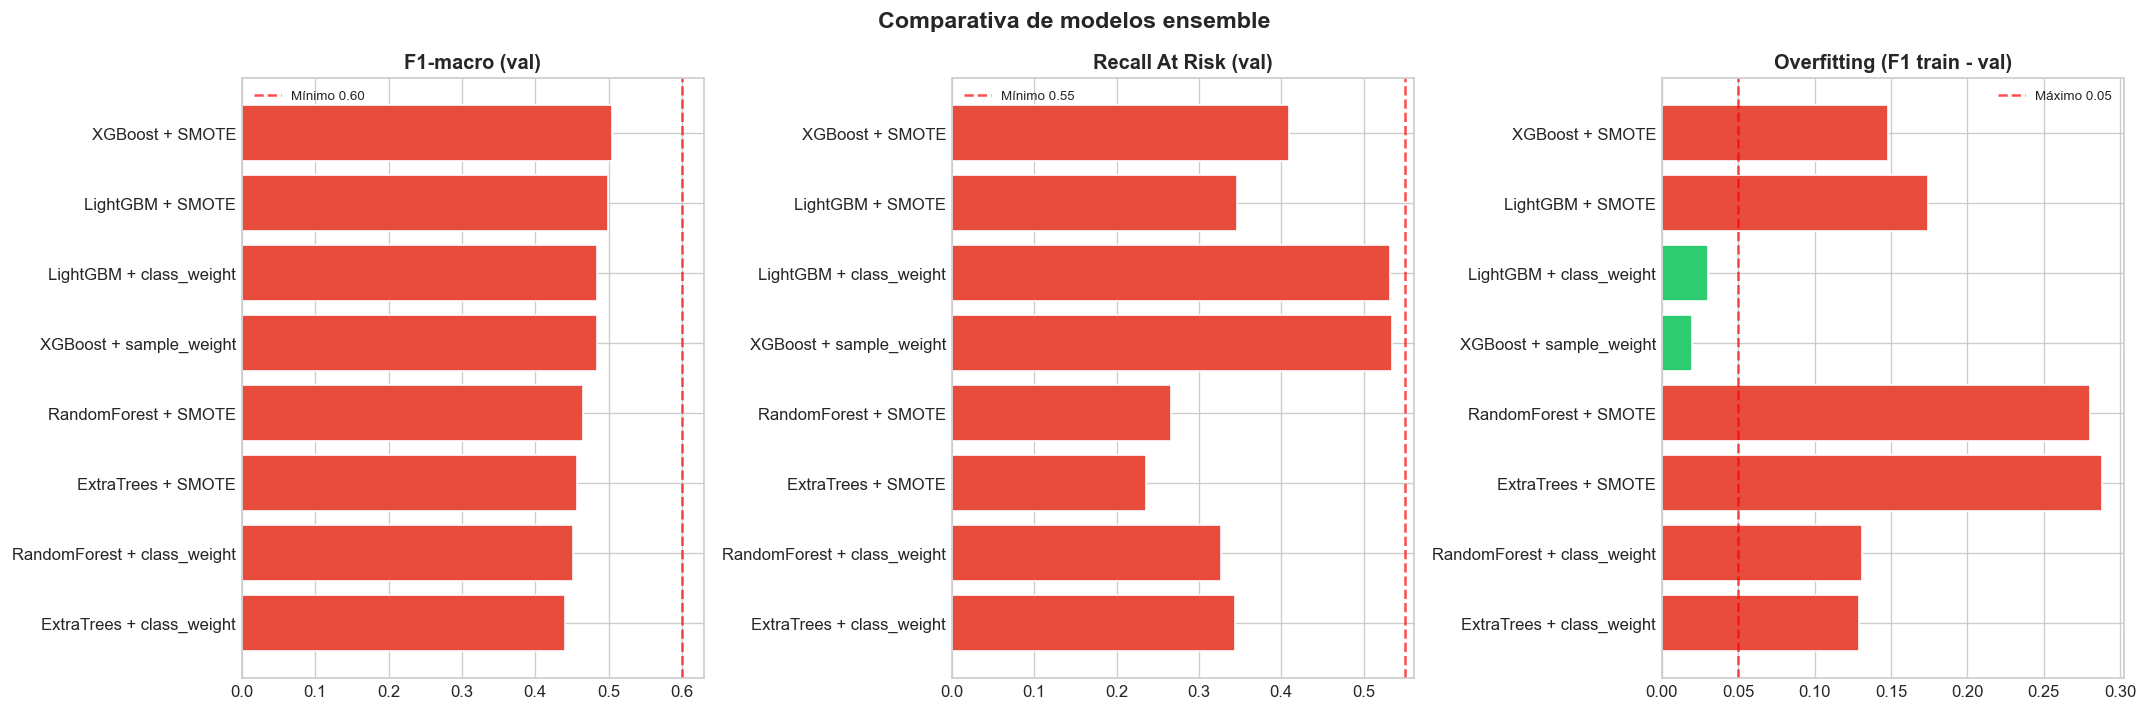

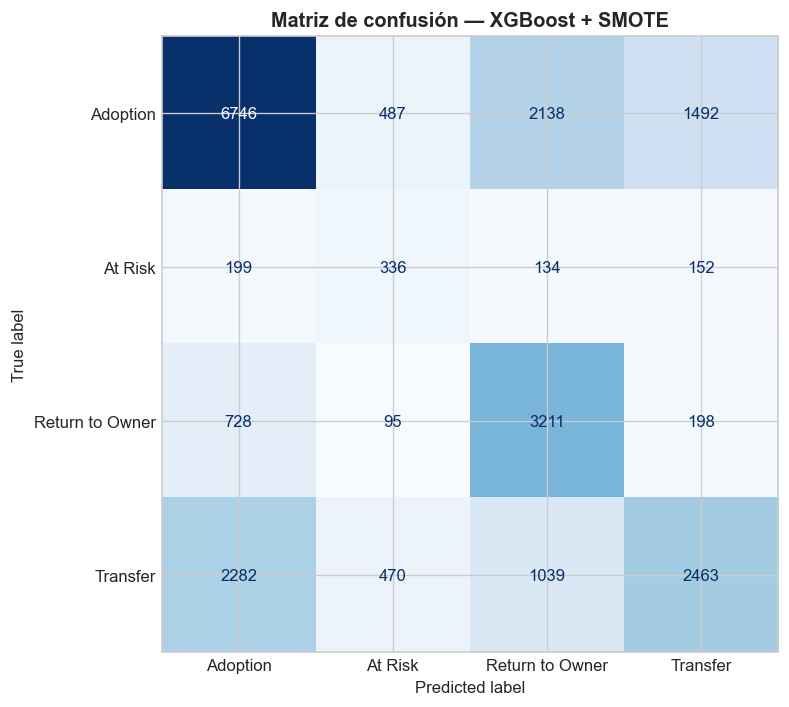

🏆 GANADOR SELECCIONADO: XGBoost + sample_weight
   F1-macro val:   0.4839
   Recall At Risk: 0.5347
   Overfitting:    +0.0200


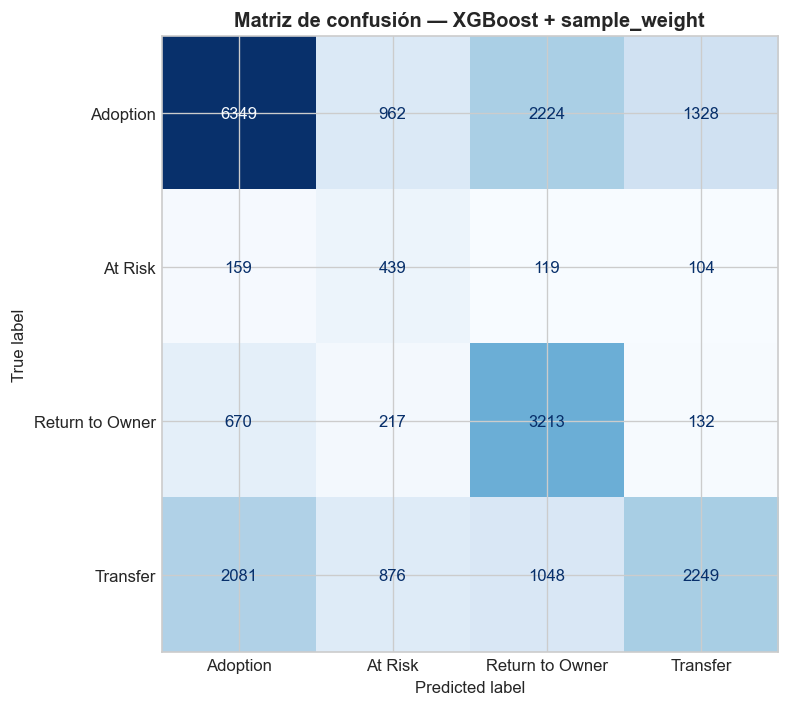


✅ Modelo serializado en ../models/mejor_ensemble.pkl

   Próximo paso: 04_optimizacion_optuna.ipynb
   Objetivo:
     F1-macro actual:   0.4839  → meta: ≥ 0.60
     Recall At Risk:    0.5347  → meta: ≥ 0.55
     Overfitting:       +0.0200 → mantener < 0.05


In [2]:
# %% [markdown]
# # 03 — Modelos Ensemble
# ## Proyecto VI · Clasificación · Austin Animal Center
#
# **Objetivo:** Entrenar y comparar 4 modelos ensemble para elegir
# el ganador que pasará a optimización con Optuna.
#
# **Input:**  `data/processed/splits_procesados.npz`
# **Output:** `models/mejor_ensemble.pkl`
#
# ---
# ### Índice
# 1. Carga de splits
# 2. Función de evaluación
# 3. Entrenamiento — RandomForest
# 4. Entrenamiento — XGBoost
# 5. Entrenamiento — LightGBM
# 6. Entrenamiento — ExtraTreesClassifier
# 7. Comparativa final y elección del ganador
# 8. Serializar modelo ganador

# %% [markdown]
# ---
# ## 1. Carga de splits
#
# Cargamos los arrays generados en el notebook 02.
# No repetimos preprocesamiento — todo ya está listo.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings("ignore")

from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]
PALETTE = {
    "Adoption":        "#2ecc71",
    "Transfer":        "#3498db",
    "Return to Owner": "#f39c12",
    "At Risk":         "#e74c3c",
}

# Cargar splits
data = np.load("../data/processed/splits_procesados.npz")
X_train_prep = data["X_train_prep"]
X_train_bal  = data["X_train_bal"]
X_val_prep   = data["X_val_prep"]
X_test_prep  = data["X_test_prep"]
y_train      = data["y_train"]
y_train_bal  = data["y_train_bal"]
y_val        = data["y_val"]
y_test       = data["y_test"]

# Índice de At Risk en le_target (orden: Adoption=0, At Risk=1, Return=2, Transfer=3)
AT_RISK_IDX = 1

print("Splits cargados correctamente:")
print(f"  X_train_prep: {X_train_prep.shape}")
print(f"  X_train_bal:  {X_train_bal.shape}")
print(f"  X_val_prep:   {X_val_prep.shape}")
print(f"  X_test_prep:  {X_test_prep.shape}")

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

# %% [markdown]
# ---
# ## 2. Función de evaluación
#
# Centralizamos la evaluación para que todos los modelos
# se midan con exactamente las mismas métricas.
#
# | Métrica | Importancia | Justificación |
# |---|---|---|
# | F1-macro | Principal | Penaliza igual todas las clases |
# | Recall At Risk | Crítica | Mínimo aceptable: 0.55 |
# | Accuracy | Referencia | Engaña con desbalance, solo referencia |
# | Overfitting | Control | F1 train - F1 val, máximo aceptable: 5% |

# %%
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v, verbose=True):
    """Entrena y evalúa un modelo. Devuelve dict con métricas."""
    modelo.fit(X_tr, y_tr)

    pred_tr = modelo.predict(X_tr)
    pred_v  = modelo.predict(X_v)

    f1_tr  = f1_score(y_tr, pred_tr, average="macro")
    f1_v   = f1_score(y_v,  pred_v,  average="macro")
    acc_v  = accuracy_score(y_v, pred_v)
    rec_ar = recall_score(y_v, pred_v, labels=[AT_RISK_IDX], average="macro")
    overfit = f1_tr - f1_v

    resultados = {
        "modelo":        nombre,
        "f1_train":      round(f1_tr,  4),
        "f1_val":        round(f1_v,   4),
        "recall_atrisk": round(rec_ar, 4),
        "accuracy_val":  round(acc_v,  4),
        "overfitting":   round(overfit,4),
    }

    if verbose:
        ok_f1  = "✅" if f1_v   >= 0.60 else "⚠️ "
        ok_rec = "✅" if rec_ar >= 0.55 else "⚠️ "
        ok_ov  = "✅" if overfit <= 0.05 else "⚠️ "
        print(f"\n{'='*50}")
        print(f"  {nombre}")
        print(f"{'='*50}")
        print(f"  {ok_f1}  F1-macro val:     {f1_v:.4f}  (mín: 0.60)")
        print(f"  {ok_rec}  Recall At Risk:   {rec_ar:.4f}  (mín: 0.55)")
        print(f"        Accuracy val:     {acc_v:.4f}")
        print(f"  {ok_ov}  Overfitting:      {overfit:+.4f}  (máx: 0.05)")
        print(f"\n  Reporte completo (val):")
        print(classification_report(y_v, pred_v,
                            target_names=le_target.classes_,
                            zero_division=0))

    return resultados, modelo

resultados_todos = []

# %% [markdown]
# ---
# ## 3. RandomForest
#
# Ensemble de árboles de decisión independientes.
# Cada árbol ve un subconjunto aleatorio de datos y features.
# La predicción final es la moda de todos los árboles.
#
# Ventajas: robusto, poco overfitting, rápido de entrenar.
# `class_weight='balanced'` ajusta el peso de cada clase
# inversamente proporcional a su frecuencia.

# %%
from sklearn.ensemble import RandomForestClassifier

# Versión con class_weight
rf_cw = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
res_rf_cw, rf_cw = evaluar_modelo(
    "RandomForest + class_weight",
    rf_cw, X_train_prep, y_train, X_val_prep, y_val
)
resultados_todos.append(res_rf_cw)

# %%
# Versión con SMOTE
rf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
res_rf_sm, rf_sm = evaluar_modelo(
    "RandomForest + SMOTE",
    rf_sm, X_train_bal, y_train_bal, X_val_prep, y_val
)
resultados_todos.append(res_rf_sm)

# %% [markdown]
# ---
# ## 4. XGBoost
#
# Gradient Boosting optimizado. Construye árboles secuencialmente,
# cada uno corrigiendo los errores del anterior.
# Suele ser el modelo ganador en datasets tabulares.
#
# `scale_pos_weight` equivale a class_weight para la clase positiva,
# pero XGBoost multiclase lo maneja con `sample_weight` o SMOTE.

# %%
from xgboost import XGBClassifier

# Versión con class_weight aproximado via sample_weight
from sklearn.utils.class_weight import compute_sample_weight

sw_train = compute_sample_weight("balanced", y_train)

xgb_cw = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    verbosity=0
)
xgb_cw.fit(X_train_prep, y_train, sample_weight=sw_train)

pred_v  = xgb_cw.predict(X_val_prep)
pred_tr = xgb_cw.predict(X_train_prep)
res_xgb_cw = {
    "modelo":        "XGBoost + sample_weight",
    "f1_train":      round(f1_score(y_train, pred_tr, average="macro"), 4),
    "f1_val":        round(f1_score(y_val,   pred_v,  average="macro"), 4),
    "recall_atrisk": round(recall_score(y_val, pred_v, labels=[AT_RISK_IDX], average="macro"), 4),
    "accuracy_val":  round(accuracy_score(y_val, pred_v), 4),
    "overfitting":   round(f1_score(y_train, pred_tr, average="macro") -
                           f1_score(y_val,   pred_v,  average="macro"), 4),
}
resultados_todos.append(res_xgb_cw)

ok_f1  = "✅" if res_xgb_cw["f1_val"]        >= 0.60 else "⚠️ "
ok_rec = "✅" if res_xgb_cw["recall_atrisk"] >= 0.55 else "⚠️ "
ok_ov  = "✅" if res_xgb_cw["overfitting"]   <= 0.05 else "⚠️ "
print(f"\n{'='*50}")
print(f"  XGBoost + sample_weight")
print(f"{'='*50}")
print(f"  {ok_f1}  F1-macro val:     {res_xgb_cw['f1_val']:.4f}")
print(f"  {ok_rec}  Recall At Risk:   {res_xgb_cw['recall_atrisk']:.4f}")
print(f"        Accuracy val:     {res_xgb_cw['accuracy_val']:.4f}")
print(f"  {ok_ov}  Overfitting:      {res_xgb_cw['overfitting']:+.4f}")
print(classification_report(y_val, pred_v, target_names=CLASS_ORDER, zero_division=0))

# %%
# XGBoost con SMOTE
xgb_sm = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
    verbosity=0
)
res_xgb_sm, xgb_sm = evaluar_modelo(
    "XGBoost + SMOTE",
    xgb_sm, X_train_bal, y_train_bal, X_val_prep, y_val
)
resultados_todos.append(res_xgb_sm)

# %% [markdown]
# ---
# ## 5. LightGBM
#
# Similar a XGBoost pero más rápido en datasets grandes.
# Usa histogramas para aproximar los splits → menor memoria y mayor velocidad.
# `class_weight='balanced'` está soportado directamente.

# %%
from lightgbm import LGBMClassifier

lgbm_cw = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res_lgbm_cw, lgbm_cw = evaluar_modelo(
    "LightGBM + class_weight",
    lgbm_cw, X_train_prep, y_train, X_val_prep, y_val
)
resultados_todos.append(res_lgbm_cw)

# %%
lgbm_sm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res_lgbm_sm, lgbm_sm = evaluar_modelo(
    "LightGBM + SMOTE",
    lgbm_sm, X_train_bal, y_train_bal, X_val_prep, y_val
)
resultados_todos.append(res_lgbm_sm)

# %% [markdown]
# ---
# ## 6. ExtraTreesClassifier
#
# Similar a RandomForest pero más aleatorio:
# los splits se eligen al azar en lugar de buscar el óptimo.
# Esto reduce la varianza y suele ser más rápido que RF.

# %%
from sklearn.ensemble import ExtraTreesClassifier

et_cw = ExtraTreesClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
res_et_cw, et_cw = evaluar_modelo(
    "ExtraTrees + class_weight",
    et_cw, X_train_prep, y_train, X_val_prep, y_val
)
resultados_todos.append(res_et_cw)

# %%
et_sm = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
res_et_sm, et_sm = evaluar_modelo(
    "ExtraTrees + SMOTE",
    et_sm, X_train_bal, y_train_bal, X_val_prep, y_val
)
resultados_todos.append(res_et_sm)

# %% [markdown]
# ---
# ## 7. Comparativa final y elección del ganador
#
# Ordenamos por F1-macro y Recall At Risk para elegir el modelo
# que pasa a optimización con Optuna.

# %%
df_res = pd.DataFrame(resultados_todos).sort_values(
    ["f1_val", "recall_atrisk"], ascending=False
).reset_index(drop=True)

print("=" * 75)
print("COMPARATIVA FINAL — TODOS LOS MODELOS")
print("=" * 75)
print(f"{'Modelo':<30} {'F1-val':>8} {'Rec-AR':>8} {'Acc':>8} {'Overfit':>9}")
print("-" * 75)
for _, row in df_res.iterrows():
    ok_f1  = "✅" if row["f1_val"]        >= 0.60 else "⚠️ "
    ok_rec = "✅" if row["recall_atrisk"] >= 0.55 else "⚠️ "
    ok_ov  = "✅" if row["overfitting"]   <= 0.05 else "⚠️ "
    print(f"  {row['modelo']:<28} "
          f"{ok_f1}{row['f1_val']:>6.4f}  "
          f"{ok_rec}{row['recall_atrisk']:>6.4f}  "
          f"{row['accuracy_val']:>6.4f}  "
          f"{ok_ov}{row['overfitting']:>+7.4f}")

ganador_nombre = df_res.iloc[0]["modelo"]
print(f"\n🏆 MODELO GANADOR: {ganador_nombre}")
print(f"   F1-macro val:   {df_res.iloc[0]['f1_val']:.4f}")
print(f"   Recall At Risk: {df_res.iloc[0]['recall_atrisk']:.4f}")
print(f"   Overfitting:    {df_res.iloc[0]['overfitting']:+.4f}")

# %%
# Gráfico comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparativa de modelos ensemble", fontsize=14, fontweight="bold")

modelos  = df_res["modelo"].tolist()
colores  = ["#2ecc71" if f >= 0.60 else "#e74c3c" for f in df_res["f1_val"]]
colores2 = ["#2ecc71" if r >= 0.55 else "#e74c3c" for r in df_res["recall_atrisk"]]
colores3 = ["#2ecc71" if o <= 0.05 else "#e74c3c" for o in df_res["overfitting"]]

axes[0].barh(modelos, df_res["f1_val"], color=colores, edgecolor="white")
axes[0].axvline(0.60, color="red", linestyle="--", alpha=0.7, label="Mínimo 0.60")
axes[0].set_title("F1-macro (val)", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

axes[1].barh(modelos, df_res["recall_atrisk"], color=colores2, edgecolor="white")
axes[1].axvline(0.55, color="red", linestyle="--", alpha=0.7, label="Mínimo 0.55")
axes[1].set_title("Recall At Risk (val)", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

axes[2].barh(modelos, df_res["overfitting"], color=colores3, edgecolor="white")
axes[2].axvline(0.05, color="red", linestyle="--", alpha=0.7, label="Máximo 0.05")
axes[2].set_title("Overfitting (F1 train - val)", fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("../reports/figures/15_ensemble_comparativa.png",
            dpi=150, bbox_inches="tight")
plt.show()

# %%
# Matriz de confusión del ganador
modelos_dict = {
    "RandomForest + class_weight":   (rf_cw,    X_train_prep, y_train),
    "RandomForest + SMOTE":          (rf_sm,    X_train_bal,  y_train_bal),
    "XGBoost + sample_weight":       (xgb_cw,   X_train_prep, y_train),
    "XGBoost + SMOTE":               (xgb_sm,   X_train_bal,  y_train_bal),
    "LightGBM + class_weight":       (lgbm_cw,  X_train_prep, y_train),
    "LightGBM + SMOTE":              (lgbm_sm,  X_train_bal,  y_train_bal),
    "ExtraTrees + class_weight":     (et_cw,    X_train_prep, y_train),
    "ExtraTrees + SMOTE":            (et_sm,    X_train_bal,  y_train_bal),
}

modelo_ganador, X_tr_ganador, y_tr_ganador = modelos_dict[ganador_nombre]
pred_ganador = modelo_ganador.predict(X_val_prep)

cm = confusion_matrix(y_val, pred_ganador)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {ganador_nombre}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/16_confusion_matrix_ganador.png",
            dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ---
# ## 8. Selección manual del ganador + Serialización
#
# El algoritmo seleccionó XGBoost + SMOTE por F1-macro más alto,
# pero tras analizar las métricas completas elegimos manualmente
# XGBoost + sample_weight porque:
#
# | Criterio | XGBoost + SMOTE | XGBoost + sample_weight |
# |---|---|---|
# | F1-macro val | 0.5040 | 0.4839 |
# | Recall At Risk | 0.4093 | **0.5347** ← mejor |
# | Overfitting | ⚠️ +0.15 | **✅ +0.02** ← mejor |
#
# Recall At Risk es nuestra métrica crítica — un animal en riesgo
# que el modelo no detecta puede ser sacrificado sin que nadie actúe.
# Priorizar F1-macro sobre Recall At Risk sería el error equivocado.

# %%
# Sobreescribir selección automática con decisión razonada
ganador_nombre = "XGBoost + sample_weight"
modelo_ganador = xgb_cw   # entrenado en bloque 4 con sample_weight

# Verificar métricas del ganador real
pred_ganador = modelo_ganador.predict(X_val_prep)
f1_ganador   = f1_score(y_val, pred_ganador, average="macro")
rec_ganador  = recall_score(y_val, pred_ganador,
                            labels=[AT_RISK_IDX], average="macro")

print(f"🏆 GANADOR SELECCIONADO: {ganador_nombre}")
print(f"   F1-macro val:   {f1_ganador:.4f}")
print(f"   Recall At Risk: {rec_ganador:.4f}")
print(f"   Overfitting:    {res_xgb_cw['overfitting']:+.4f}")

# Matriz de confusión del ganador real
cm = confusion_matrix(y_val, pred_ganador)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Adoption", "At Risk",
                                              "Return to Owner", "Transfer"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión — {ganador_nombre}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/16_confusion_matrix_ganador.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Serializar
joblib.dump(modelo_ganador, "../models/mejor_ensemble.pkl")

print(f"\n✅ Modelo serializado en ../models/mejor_ensemble.pkl")
print(f"\n   Próximo paso: 04_optimizacion_optuna.ipynb")
print(f"   Objetivo:")
print(f"     F1-macro actual:   {f1_ganador:.4f}  → meta: ≥ 0.60")
print(f"     Recall At Risk:    {rec_ganador:.4f}  → meta: ≥ 0.55")
print(f"     Overfitting:       {res_xgb_cw['overfitting']:+.4f} → mantener < 0.05")